In [99]:
import pyproj
import math
import numpy as np
import matplotlib.pyplot as plt

from math import sin, cos, tan, atan, asin, sqrt, ceil, floor


In [100]:
frequency_hz = 5_000_000_000
latA, lonA, altA_m = (40.650, -73.800, 100.0)
latB, lonB, altB_m = (40.7173, -74.0060, 10000.0)
alpha = 0.8
t = 12000

In [101]:
nys_crs = pyproj.CRS.from_string("EPSG:6539+6360")
gps_crs = pyproj.CRS.from_string("EPSG:4326+5773")
t_to_nys = pyproj.Transformer.from_crs(gps_crs, nys_crs, always_xy=False)
xA, yA, zA = t_to_nys.transform(latA, lonA, altA_m)
xB, yB, zB = t_to_nys.transform(latB, lonB, altB_m)


deltaX = xB - xA
deltaY = yB - yA
deltaZ = zB - zA

xC, yC, zC = (xA + xB) / 2, (yA + yB) / 2, (zA + zB) / 2

L = sqrt(deltaX**2 + deltaY**2 + deltaZ**2)

In [102]:
theta = atan(-deltaY/deltaX)
phi = atan(-deltaZ/deltaX)

rho = asin(deltaZ/L)
rho2 = atan(tan(phi) * cos(theta))

omega = atan(cos(theta) / (sin(theta) * cos(phi)))

theta_deg = math.degrees(theta)
phi_deg = math.degrees(phi)
rho_deg = math.degrees(rho)
omega_deg = math.degrees(omega)


In [103]:
# Alternative construction of y hat with norm instead of angles
y_hat = np.append(np.array([deltaX, deltaY, deltaZ]) / L, 1)

In [104]:
R_ellipsoid_to_global = np.array([
    [cos(phi) * sin(theta) * cos(rho), - cos(theta) * cos(rho), sin(phi), 0],
    [sin(rho) * sin(phi) + cos(phi) * cos(theta) * cos(rho), sin(theta) * cos(rho), 0, 0],
    [-sin(phi) * cos(rho) * sin(theta), sin(rho), cos(phi), 0],
    [0, 0, 0, 1],
])


In [105]:
speed_of_light = 299_792_458 # m/s
wavelength_meters = speed_of_light / frequency_hz
wavelength_usft = wavelength_meters / 0.30480061

semi_major = (L + wavelength_usft / 2) / 2
semi_minor = (sqrt(wavelength_usft * L) / 2) * alpha
Q_pure_fresnel = np.diag([
    1/semi_minor**2,
    1/semi_major**2,
    1/semi_minor**2,
    -1
])

max_t = np.linalg.norm(np.array([semi_minor, semi_major]) * np.array([sin(omega), cos(omega)]))
t_bounds = (-max_t, max_t)
t_bounds


(np.float64(-12228.11834828034), np.float64(12228.11834828034))

In [106]:
T_centered_to_global = np.array([
    [1, 0, 0, xC],
    [0, 1, 0, yC],
    [0, 0, 1, zC],
    [0, 0, 0, 1]
])
T_centered_to_global

array([[1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.01116723e+06],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 1.88380286e+05],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 1.65682083e+04],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])

In [107]:
A_ellipsoid_to_global = T_centered_to_global @ R_ellipsoid_to_global
A_global_to_ellipsoid = np.linalg.inv(A_ellipsoid_to_global)

### Validate the coordinate transformations behave as expected for some test points

In [108]:
A_global_to_ellipsoid @ np.array([xC, yC, zC, 1]) - np.array([0, 0, 0, 1])

array([ 0.00000000e+00,  1.16415322e-10, -5.82076609e-11,  0.00000000e+00])

In [109]:
A_ellipsoid_to_global @ np.array([0, L / 2, 0, 1]) - np.array([xB, yB, zB, 1])

array([0., 0., 0., 0.])

In [110]:
A_ellipsoid_to_global @ np.array([0, 0, 0, 1]) - np.array([xC, yC, zC, 1])


array([0., 0., 0., 0.])

In [111]:
A_ellipsoid_to_global @ np.array([0, -L / 2, 0, 1]) - np.array([xA, yA, zA, 1])

array([1.16415322e-10, 0.00000000e+00, 5.68434189e-13, 0.00000000e+00])

### Compute the intersection

In [112]:
Q_global = np.linalg.matrix_transpose(A_global_to_ellipsoid) @ Q_pure_fresnel @ A_global_to_ellipsoid
np.linalg.inv(Q_global)

array([[-1.02164230e+12, -1.90833451e+11, -1.72173801e+10,
        -1.01116721e+06],
       [-1.90833451e+11, -3.53376046e+10, -2.92253897e+09,
        -1.88380283e+05],
       [-1.72173801e+10, -2.92253897e+09, -1.07613894e+07,
        -1.65682081e+04],
       [-1.01116721e+06, -1.88380283e+05, -1.65682081e+04,
        -9.99999985e-01]])

In [113]:
# For reference, the center coordinates, which should agree with inv(Q_global) @ [0, 0, 0, -1]
xC, yC, zC

(1011167.2277252311, 188380.2855814694, 16568.208333333336)

In [114]:
E_global = np.array([
    [1, 0, xC],
    [0, 0, yC + t],
    [0, 1, zC],
    [0, 0, 1]
])
E_global

array([[1.00000000e+00, 0.00000000e+00, 1.01116723e+06],
       [0.00000000e+00, 0.00000000e+00, 1.76380286e+05],
       [0.00000000e+00, 1.00000000e+00, 1.65682083e+04],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])

In [115]:
C = np.linalg.matrix_transpose(E_global) @ Q_global @ E_global
np.linalg.inv(C)

array([[-2.12821408e+10,  1.20930317e+10, -7.58800214e+05],
       [ 1.20930317e+10, -6.87155278e+09,  4.31168752e+05],
       [-7.58800214e+05,  4.31168752e+05, -2.70544859e+01]])

In [116]:
ellipse_offset_homogenous = np.linalg.inv(C)[:, 2]

ellipse_offset = ellipse_offset_homogenous[:2] / ellipse_offset_homogenous[2]

In [117]:
B_ellipse_normalization = np.array([
    [1, 0, ellipse_offset[0]],
    [0, 1, ellipse_offset[1]],
    [0, 0, 1]
])

In [118]:
C_norm = np.linalg.matrix_transpose(B_ellipse_normalization) @ C @ B_ellipse_normalization

a = C_norm[0, 0]
b = C_norm[1, 0]
c = C_norm[1, 1]
f = C_norm[2, 2]

C_norm

array([[ 1.52170546e-04,  1.70906002e-04, -6.66133815e-16],
       [ 1.70906002e-04,  3.55829648e-04,  3.33066907e-16],
       [-6.66133815e-16,  3.33066907e-16, -3.69624470e-02]])

In [119]:
max_x_offset = sqrt(c*f/(b**2-a*c))
min_x_offset = -sqrt(c*f/(b**2-a*c))
x_offset_bounds = np.array((min_x_offset, max_x_offset))
x_offset_bounds

array([-22.96525215,  22.96525215])

In [120]:
# __BOTH__ BOUNDS ARE __INCLUSIVE__
ellipse_offset_global_x_offset = ellipse_offset[0] + xC
x_bounds_global = ellipse_offset_global_x_offset + x_offset_bounds
x_grid_bounds_global = np.array([ceil(x_bounds_global[0]), floor(x_bounds_global[1])])

x_grid_width = x_grid_bounds_global[1] - x_grid_bounds_global[0]
x_grid_bounds_ellipse = x_grid_bounds_global - ellipse_offset_global_x_offset
x_grid_global = np.linspace(x_grid_bounds_global[0], x_grid_bounds_global[1], x_grid_width + 1, dtype=np.int64) # +1 is to convert width to an inclusive upper bound
x_grid_ellipse = x_grid_global - ellipse_offset_global_x_offset

In [121]:
sqrt_term = np.sqrt(x_grid_ellipse**2 * ((b**2 - a*c) / c**2) - (f / c))
lin_term = (-b/c) * x_grid_ellipse

lower_bounds_ellipse = lin_term - sqrt_term
upper_bounds_ellipse = lin_term + sqrt_term
lower_bounds_ellipse, upper_bounds_ellipse

(array([  8.36878837,   6.48429762,   5.03786637,   3.7934004 ,
          2.67494786,   1.64630854,   0.6868224 ,  -0.21662878,
         -1.07298558,  -1.8886547 ,  -2.66839994,  -3.4158633 ,
         -4.13388834,  -4.82473013,  -5.4901969 ,  -6.13174833,
         -6.75056549,  -7.34760147,  -7.92361843,  -8.47921494,
         -9.01484594,  -9.53083715, -10.0273949 , -10.50461221,
        -10.96247148, -11.40084395, -11.81948601, -12.21803194,
        -12.59598277, -12.95269017, -13.28733441, -13.59889421,
        -13.88610581, -14.14740701, -14.3808593 , -14.58403776,
        -14.753871  , -14.88640124, -14.97640982, -15.01680313,
        -14.99753934, -14.90358891, -14.71058397, -14.37379617,
        -13.79073307, -12.54071923]),
 array([13.09150338, 14.01538839, 14.50121389, 14.78507412, 14.94292092,
        15.01095449, 15.00983489, 14.95268033, 14.84843139, 14.70349477,
        14.52263426, 14.30949188, 14.06691118, 13.79714723, 13.50200825,
        13.18295394, 12.84116536, 12.47

In [122]:
ellipse_offset_global_z_offset = ellipse_offset[1] + zC
lower_bounds_global, upper_bounds_global = lower_bounds_ellipse + ellipse_offset_global_z_offset, upper_bounds_ellipse + ellipse_offset_global_z_offset
lower_bounds_global, upper_bounds_global

(array([639.52498577, 637.64049502, 636.19406378, 634.94959781,
        633.83114527, 632.80250595, 631.84301981, 630.93956862,
        630.08321183, 629.2675427 , 628.48779747, 627.7403341 ,
        627.02230907, 626.33146727, 625.6660005 , 625.02444908,
        624.40563191, 623.80859594, 623.23257897, 622.67698247,
        622.14135147, 621.62536026, 621.12880251, 620.65158519,
        620.19372592, 619.75535345, 619.3367114 , 618.93816546,
        618.56021464, 618.20350723, 617.86886299, 617.5573032 ,
        617.27009159, 617.00879039, 616.7753381 , 616.57215965,
        616.40232641, 616.26979617, 616.17978758, 616.13939427,
        616.15865807, 616.2526085 , 616.44561344, 616.78240124,
        617.36546434, 618.61547817]),
 array([644.24770079, 645.1715858 , 645.6574113 , 645.94127152,
        646.09911832, 646.1671519 , 646.1660323 , 646.10887774,
        646.00462879, 645.85969217, 645.67883167, 645.46568929,
        645.22310858, 644.95334463, 644.65820566, 644.33915134,
  

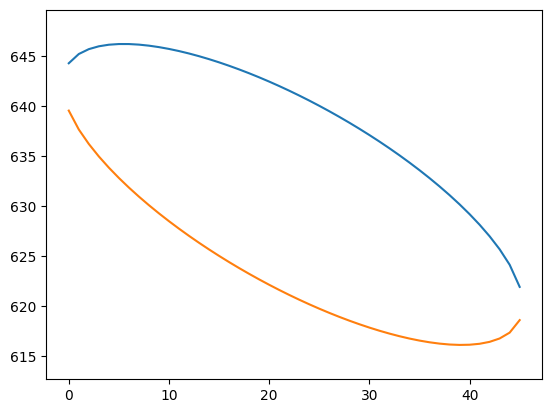

In [123]:
plt.plot(upper_bounds_global)
plt.plot(lower_bounds_global)
ax = plt.gca()
ax.set_aspect('equal', adjustable='datalim')


### Correct for distortion due to the conic projection of the NYS Plane that we just worked in

Strictly speaking, the below implementation is not correct, since it assumes constant distortion radially from the LOS line. In reality, there is increased distortion further from the line, but since the radius of the zone <<< length of the line, we can neglect this effect to make the computation SIGNIFICANTLY easier. It's also an approximation even on the centerline, since it assumes a spherical earth. However, we expect these errors to be < 0.1 usft so we do not care

In [141]:
x_grid_from_C = x_grid_global - xC

R_to_correction_func = np.array([
    [sin(theta), cos(theta)],
    [-cos(theta), sin(theta)]
])

grid_coordinates_from_C = x_grid_from_C.copy()
grid_coordinates_from_C = np.vstack((grid_coordinates_from_C, np.full(grid_coordinates_from_C.shape, t)))

distance_from_center = (R_to_correction_func @ grid_coordinates_from_C)[1]
distance_from_center

# x_grid_global
# y_val = yC + t

array([-30485.86198452, -30486.78137112, -30487.70075773, -30488.62014433,
       -30489.53953093, -30490.45891753, -30491.37830413, -30492.29769073,
       -30493.21707733, -30494.13646394, -30495.05585054, -30495.97523714,
       -30496.89462374, -30497.81401034, -30498.73339694, -30499.65278354,
       -30500.57217015, -30501.49155675, -30502.41094335, -30503.33032995,
       -30504.24971655, -30505.16910315, -30506.08848975, -30507.00787635,
       -30507.92726296, -30508.84664956, -30509.76603616, -30510.68542276,
       -30511.60480936, -30512.52419596, -30513.44358256, -30514.36296917,
       -30515.28235577, -30516.20174237, -30517.12112897, -30518.04051557,
       -30518.95990217, -30519.87928877, -30520.79867538, -30521.71806198,
       -30522.63744858, -30523.55683518, -30524.47622178, -30525.39560838,
       -30526.31499498, -30527.23438158])

In [144]:
earth_radius_m = 6_369_160 # (approx) In NYC
centerline_length = 2*semi_major
correction_factor = np.sqrt(earth_radius_m**2 - distance_from_center**2) - math.sqrt(earth_radius_m**2 - (1/4) * centerline_length**2)
correction_factor

array([23.60827355, 23.60387281, 23.59947194, 23.59507093, 23.59066979,
       23.58626851, 23.5818671 , 23.57746556, 23.57306389, 23.56866209,
       23.56426015, 23.55985808, 23.55545588, 23.55105354, 23.54665107,
       23.54224847, 23.53784574, 23.53344287, 23.52903987, 23.52463674,
       23.52023348, 23.51583008, 23.51142655, 23.50702288, 23.50261909,
       23.49821516, 23.4938111 , 23.48940691, 23.48500258, 23.48059812,
       23.47619353, 23.4717888 , 23.46738395, 23.46297896, 23.45857383,
       23.45416858, 23.44976319, 23.44535767, 23.44095202, 23.43654623,
       23.43214031, 23.42773426, 23.42332807, 23.41892176, 23.41451531,
       23.41010872])

In [146]:
corrected_upper = upper_bounds_global - correction_factor
corrected_lower = lower_bounds_global - correction_factor

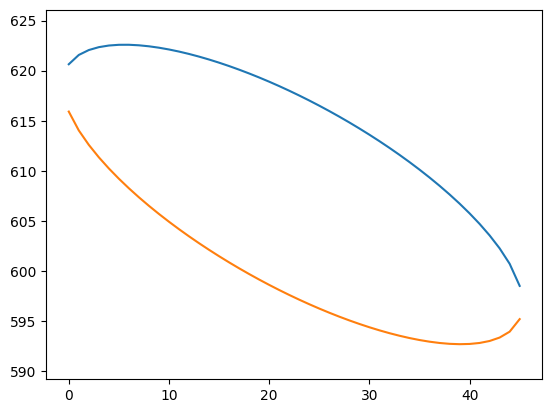

In [147]:
plt.plot(corrected_upper)
plt.plot(corrected_lower)
ax = plt.gca()
ax.set_aspect('equal', adjustable='datalim')